1. Скачайте набор данных MNIST и любой другой MNIST-подобный набор данных (с однокональным входом 28 на 28), например FashionMNIST. Их загрузчики можно найти в модуле datasets библиотеке torchvision, либо загруть с яндекс-диска: https://disk.yandex.ru/d/8dzDTw5u44mgPw и  https://disk.yandex.ru/d/unX7snxQ57V1oA. Первые 16 байт idx3-ubyte файла — заголовок, который содержит формат, число картинок, высоту и ширину. Заголовок idx1-ubyte файла состоит из 8 байт, содержит только формат и длину.

2. Выберите любой достаточно продвинутый фреймворк для глубокого обучения, рекомендуется испльзовать PyTorch.

In [1]:
%matplotlib inline

import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device("mps")

def set_seed(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed()

batch_size = 110
epochs = 10
lr = 0.001

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=data_transform)
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=data_transform)
fashion_train = datasets.FashionMNIST(root="./data", train=True, download=True, transform=data_transform)
fashion_test = datasets.FashionMNIST(root="./data", train=False, download=True, transform=data_transform)

mnist_train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)
fashion_train_loader = DataLoader(fashion_train, batch_size=batch_size, shuffle=True)
fashion_test_loader = DataLoader(fashion_test, batch_size=batch_size, shuffle=False)

/Users/moahim/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


3. Реализуйте архитектуру свёрточной сети для классификации набора данных MNIST. Выберите эмпирический риск, лучше использовать перекрёстную энтропию.

In [2]:
class DualHeadCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 48, 3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.body = nn.Sequential(
            nn.Conv2d(48, 96, 3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.flatten = nn.Flatten()
        feat = 96 * 7 * 7
        self.head1 = nn.Linear(feat, 10)
        self.head2 = nn.Linear(feat, 10)

    def forward(self, x, head):
        z = self.stem(x)
        z = self.body(z)
        z = self.flatten(z)
        if head == 1:
            return self.head1(z)
        return self.head2(z)

    def trunk_parameters(self):
        return list(self.stem.parameters()) + list(self.body.parameters())


def train_one_epoch(model, loader, head, optimizer, criterion, dev):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x = x.to(dev)
        y = y.to(dev)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x, head)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, head, criterion, dev):
    model.eval()
    total_loss = 0.0
    correct = 0
    n = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(dev)
            y = y.to(dev)
            logits = model(x, head)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

model = DualHeadCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.trunk_parameters() + list(model.head1.parameters()), lr=lr)

4. Обучите архитектуру и постройте кривую обучения для тренировочного и тестового множества. Используйте целевую функцию для задачи классификации.

5. Добавьте в архитектуру новую «голову». Сохраните значения всех обучаемых параметров: общих свёрточных слоёв, первой и ещё не обученной второй «головы».

In [3]:
mnist_stage1_train = []
mnist_stage1_test = []
mnist_stage1_acc = []

epoch_bar = tqdm(range(epochs), desc="MNIST trunk+head1")
for _ in epoch_bar:
    tr = train_one_epoch(model, mnist_train_loader, 1, optimizer, criterion, device)
    te, acc = evaluate(model, mnist_test_loader, 1, criterion, device)
    mnist_stage1_train.append(tr)
    mnist_stage1_test.append(te)
    mnist_stage1_acc.append(acc)
    epoch_bar.set_postfix(train=f"{tr:.4f}", test=f"{te:.4f}", acc=f"{acc:.4f}")

torch.save(
    {
        "stem": model.stem.state_dict(),
        "body": model.body.state_dict(),
        "head1": model.head1.state_dict(),
        "head2": model.head2.state_dict(),
    },
    "ml2_after_mnist.pt",
)


MNIST trunk+head1:   0%|          | 0/10 [00:00<?, ?it/s]

MNIST trunk+head1: 100%|██████████| 10/10 [01:11<00:00,  7.10s/it, acc=0.9906, test=0.0365, train=0.0116]


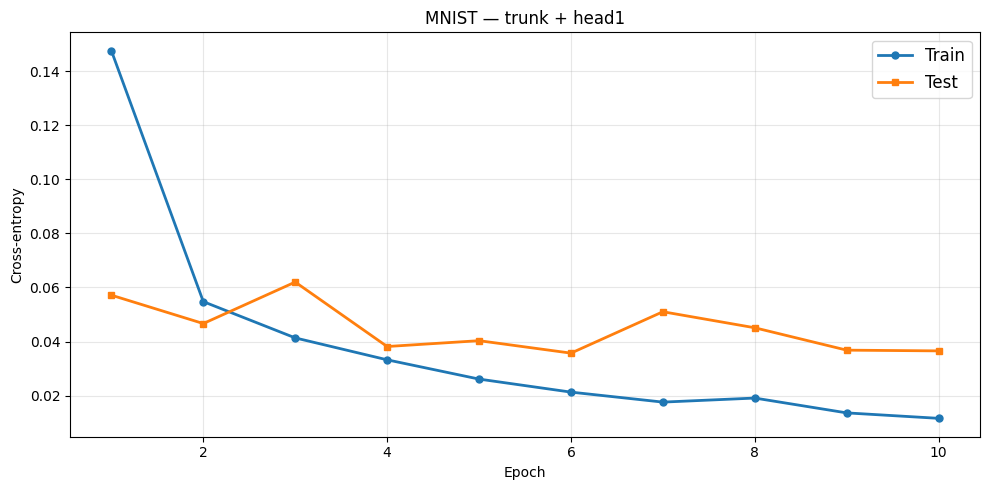

In [17]:
plt.figure(figsize=(10, 5))
ep = range(1, epochs + 1)
plt.plot(ep, mnist_stage1_train, 'o-', linewidth=2, markersize=5, label='Train')
plt.plot(ep, mnist_stage1_test, 's-', linewidth=2, markersize=5, label='Test')
plt.title('MNIST — trunk + head1')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

6. Обучите вторую «голову» для классификации второго набора данных. При этом параметры общих свёрточных преобразований должны быть заморожены. Постройте кривые обучения для второй задачи.

In [4]:
for p in model.stem.parameters():
    p.requires_grad = False
for p in model.body.parameters():
    p.requires_grad = False

optimizer = optim.Adam(model.head2.parameters(), lr=lr)

fashion_frozen_train = []
fashion_frozen_test = []
fashion_frozen_acc = []

bar = tqdm(range(epochs), desc="Fashion head2 frozen trunk")
for _ in bar:
    tr = train_one_epoch(model, fashion_train_loader, 2, optimizer, criterion, device)
    te, acc = evaluate(model, fashion_test_loader, 2, criterion, device)
    fashion_frozen_train.append(tr)
    fashion_frozen_test.append(te)
    fashion_frozen_acc.append(acc)
    bar.set_postfix(train=f"{tr:.4f}", test=f"{te:.4f}", acc=f"{acc:.4f}")

torch.save(
    {
        "stem": model.stem.state_dict(),
        "body": model.body.state_dict(),
        "head1": model.head1.state_dict(),
        "head2": model.head2.state_dict(),
    },
    "ml2_after_fashion_frozen.pt",
)


Fashion head2 frozen trunk: 100%|██████████| 10/10 [00:47<00:00,  4.77s/it, acc=0.8980, test=0.3182, train=0.1751]


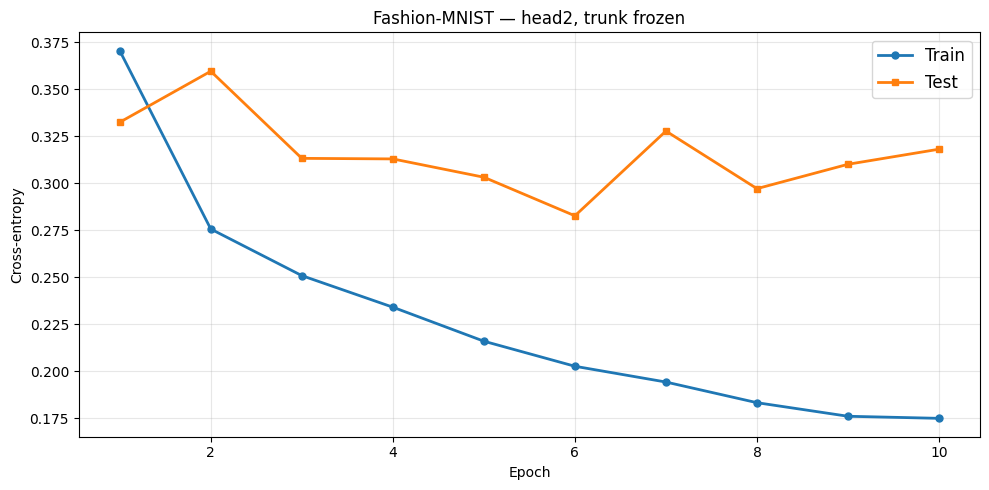

In [5]:
plt.figure(figsize=(10, 5))
ep = range(1, epochs + 1)
plt.plot(ep, fashion_frozen_train, 'o-', linewidth=2, markersize=5, label='Train')
plt.plot(ep, fashion_frozen_test, 's-', linewidth=2, markersize=5, label='Test')
plt.title('Fashion-MNIST — head2, trunk frozen')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

7. Разморозьте параметры общих свёрточных преобразований и дообучите вторую голову. Постройте кривые обучения для первой и второй задачи.

In [6]:
for p in model.stem.parameters():
    p.requires_grad = True
for p in model.body.parameters():
    p.requires_grad = True

optimizer = optim.Adam(
    model.trunk_parameters() + list(model.head1.parameters()) + list(model.head2.parameters()),
    lr=lr,
)

mnist_ft_train = []
mnist_ft_test = []
fashion_ft_train = []
fashion_ft_test = []
mnist_ft_acc = []
fashion_ft_acc = []

bar = tqdm(range(epochs), desc="Finetune both heads")
for _ in bar:
    f_tr = train_one_epoch(model, fashion_train_loader, 2, optimizer, criterion, device)
    m_te, m_acc = evaluate(model, mnist_test_loader, 1, criterion, device)
    f_te, f_acc = evaluate(model, fashion_test_loader, 2, criterion, device)
    mnist_ft_test.append(m_te)
    fashion_ft_train.append(f_tr)
    fashion_ft_test.append(f_te)
    mnist_ft_acc.append(m_acc)
    fashion_ft_acc.append(f_acc)
    bar.set_postfix(
        m_te=f"{m_te:.3f}",
        f_tr=f"{f_tr:.3f}",
        f_te=f"{f_te:.3f}",
        m_acc=f"{m_acc:.3f}",
        f_acc=f"{f_acc:.3f}",
    )


Finetune both heads: 100%|██████████| 10/10 [01:17<00:00,  7.78s/it, f_acc=0.910, f_te=0.306, f_tr=0.091, m_acc=0.958, m_te=0.153]


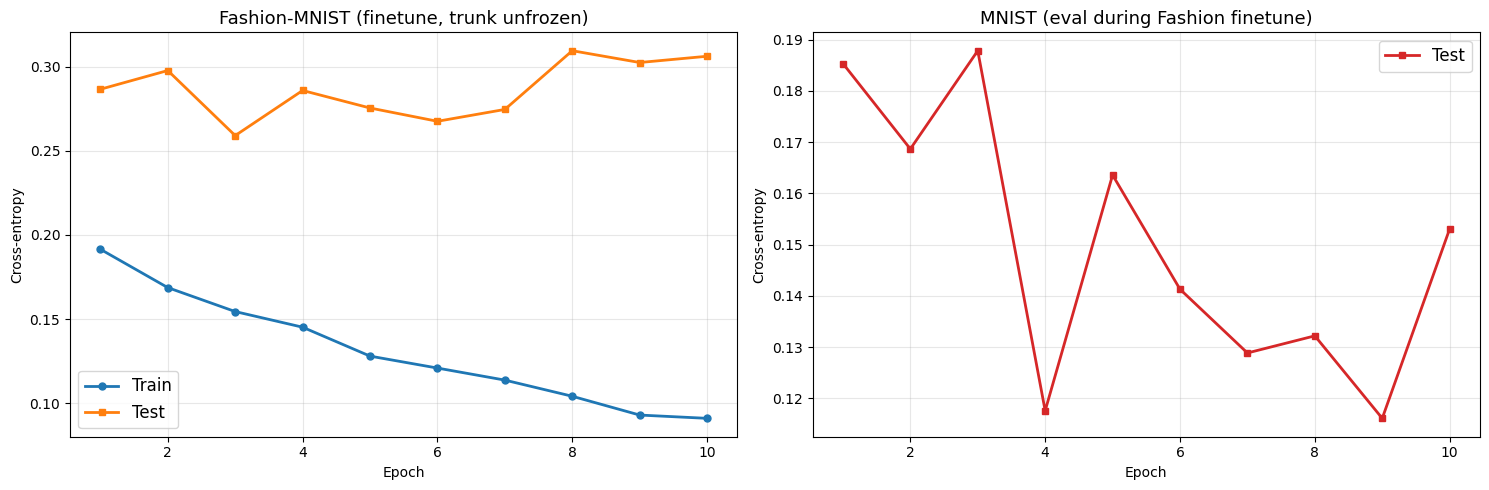

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ep = range(1, epochs + 1)

ax1.plot(ep, fashion_ft_train, 'o-', linewidth=2, markersize=5, label='Train')
ax1.plot(ep, fashion_ft_test, 's-', linewidth=2, markersize=5, label='Test')
ax1.set_title('Fashion-MNIST (finetune, trunk unfrozen)', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy')
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3)

ax2.plot(ep, mnist_ft_test, 's-', linewidth=2, markersize=5, color='tab:red', label='Test')
ax2.set_title('MNIST (eval during Fashion finetune)', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Cross-entropy')
ax2.legend(fontsize=12)
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

8. Загрузите сохранённые параметры для всех преобразований. Обучите вторую голову, при этом параметры общих свёрточных преобразований должны быть сразу разморожены. Постройте кривые обучения для первой и второй задачи.

In [8]:
model_reload = DualHeadCNN().to(device)
ckpt = torch.load("ml2_after_mnist.pt", map_location=device)
model_reload.stem.load_state_dict(ckpt["stem"])
model_reload.body.load_state_dict(ckpt["body"])
model_reload.head1.load_state_dict(ckpt["head1"])
model_reload.head2.load_state_dict(ckpt["head2"])

optimizer = optim.Adam(
    model_reload.trunk_parameters() + list(model_reload.head2.parameters()),
    lr=lr,
)

reload_fashion_train = []
reload_fashion_test = []
reload_mnist_train_eval = []
reload_mnist_test_eval = []
reload_fashion_acc = []
reload_mnist_acc = []

bar = tqdm(range(epochs), desc="Checkpoint reload Fashion+trunk")
for _ in bar:
    f_tr = train_one_epoch(model_reload, fashion_train_loader, 2, optimizer, criterion, device)
    f_te, f_acc = evaluate(model_reload, fashion_test_loader, 2, criterion, device)
    m_tr, _ = evaluate(model_reload, mnist_train_loader, 1, criterion, device)
    m_te, m_acc = evaluate(model_reload, mnist_test_loader, 1, criterion, device)
    reload_fashion_train.append(f_tr)
    reload_fashion_test.append(f_te)
    reload_mnist_train_eval.append(m_tr)
    reload_mnist_test_eval.append(m_te)
    reload_fashion_acc.append(f_acc)
    reload_mnist_acc.append(m_acc)
    bar.set_postfix(
        f_tr=f"{f_tr:.3f}",
        f_te=f"{f_te:.3f}",
        m_tr=f"{m_tr:.3f}",
        m_te=f"{m_te:.3f}",
        f_acc=f"{f_acc:.3f}",
        m_acc=f"{m_acc:.3f}",
    )


Checkpoint reload Fashion+trunk: 100%|██████████| 10/10 [01:58<00:00, 11.85s/it, f_acc=0.918, f_te=0.263, f_tr=0.093, m_acc=0.883, m_te=0.427, m_tr=0.395]


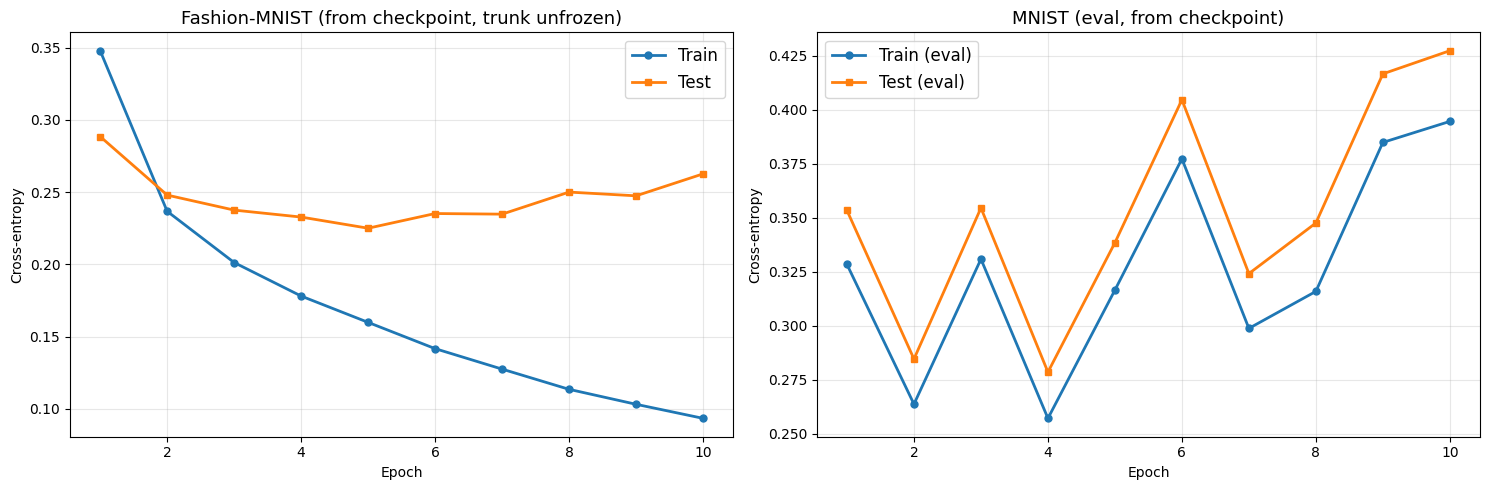

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ep = range(1, epochs + 1)

ax1.plot(ep, reload_fashion_train, 'o-', linewidth=2, markersize=5, label='Train')
ax1.plot(ep, reload_fashion_test, 's-', linewidth=2, markersize=5, label='Test')
ax1.set_title('Fashion-MNIST (from checkpoint, trunk unfrozen)', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy')
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3)

ax2.plot(ep, reload_mnist_train_eval, 'o-', linewidth=2, markersize=5, label='Train (eval)')
ax2.plot(ep, reload_mnist_test_eval, 's-', linewidth=2, markersize=5, label='Test (eval)')
ax2.set_title('MNIST (eval, from checkpoint)', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Cross-entropy')
ax2.legend(fontsize=12)
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

9. Заполните все параметры случайными значениями. Заморозьте несколько начальных свёрточных слоёв. Обучите оставшиеся слои для второй задачи. Постройте кривые обучения для второй задачи. Если модель совсем не будет обучаться, попробуйте уменьшить число начальных замороженных слоёв.

In [ ]:

model_partial = DualHeadCNN().to(device)
for p in model_partial.stem.parameters():
    p.requires_grad = False

optimizer = optim.Adam(
    list(model_partial.body.parameters()) + list(model_partial.head2.parameters()),
    lr=lr,
)

partial_train = []
partial_test = []
partial_mnist_train = []
partial_mnist_test = []
partial_acc = []

bar = tqdm(range(epochs), desc="Random init stem frozen")
for _ in bar:
    tr = train_one_epoch(model_partial, fashion_train_loader, 2, optimizer, criterion, device)
    te, acc = evaluate(model_partial, fashion_test_loader, 2, criterion, device)
    m_tr, _ = evaluate(model_partial, mnist_train_loader, 1, criterion, device)
    m_te, m_acc = evaluate(model_partial, mnist_test_loader, 1, criterion, device)
    partial_train.append(tr)
    partial_test.append(te)
    partial_mnist_train.append(m_tr)
    partial_mnist_test.append(m_te)
    partial_acc.append(acc)
    bar.set_postfix(train=f"{tr:.4f}", test=f"{te:.4f}", acc=f"{acc:.4f}")

Random init stem frozen: 100%|██████████| 10/10 [01:43<00:00, 10.35s/it, acc=0.9148, test=0.2570, train=0.1464]


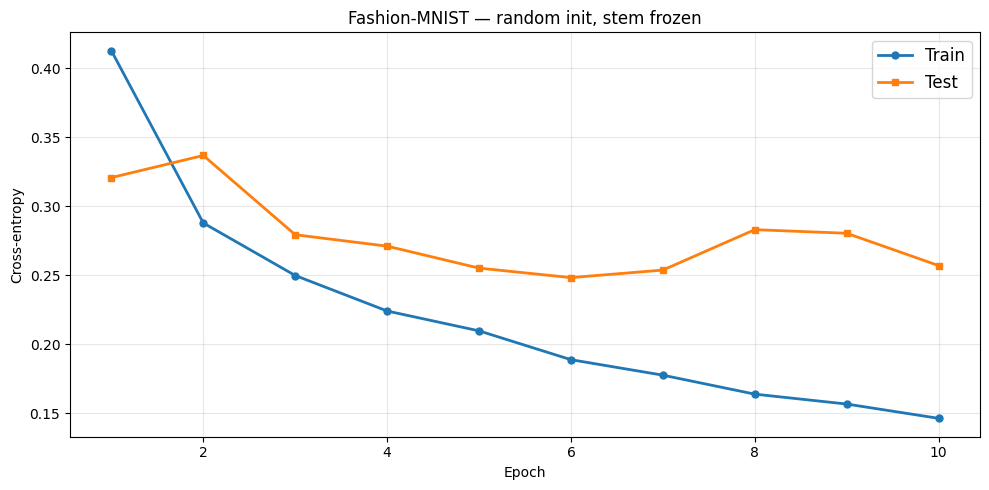

In [11]:
plt.figure(figsize=(10, 5))
ep = range(1, epochs + 1)
plt.plot(ep, partial_train, 'o-', linewidth=2, markersize=5, label='Train')
plt.plot(ep, partial_test, 's-', linewidth=2, markersize=5, label='Test')
plt.title('Fashion-MNIST — random init, stem frozen')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

10. Отобразите все кривые обучения на одном графике.

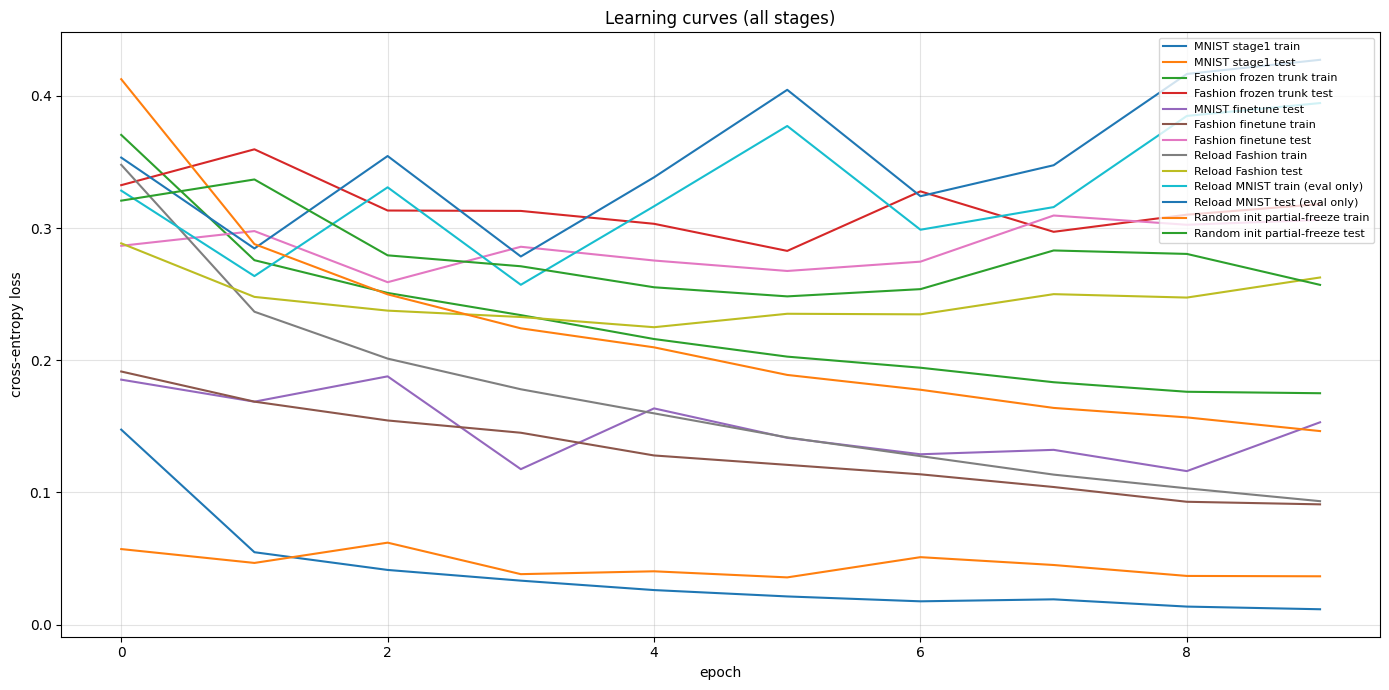

In [12]:
plt.figure(figsize=(14, 7))


def line(y, lab):
    if len(y) == 0:
        return
    plt.plot(np.arange(len(y)), y, label=lab)


line(mnist_stage1_train, "MNIST stage1 train")
line(mnist_stage1_test, "MNIST stage1 test")
line(fashion_frozen_train, "Fashion frozen trunk train")
line(fashion_frozen_test, "Fashion frozen trunk test")
line(mnist_ft_train, "MNIST finetune train")
line(mnist_ft_test, "MNIST finetune test")
line(fashion_ft_train, "Fashion finetune train")
line(fashion_ft_test, "Fashion finetune test")
line(reload_fashion_train, "Reload Fashion train")
line(reload_fashion_test, "Reload Fashion test")
line(reload_mnist_train_eval, "Reload MNIST train (eval only)")
line(reload_mnist_test_eval, "Reload MNIST test (eval only)")
line(partial_train, "Random init partial-freeze train")
line(partial_test, "Random init partial-freeze test")

plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Learning curves (all stages)")
plt.legend(loc="upper right", fontsize=8)
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


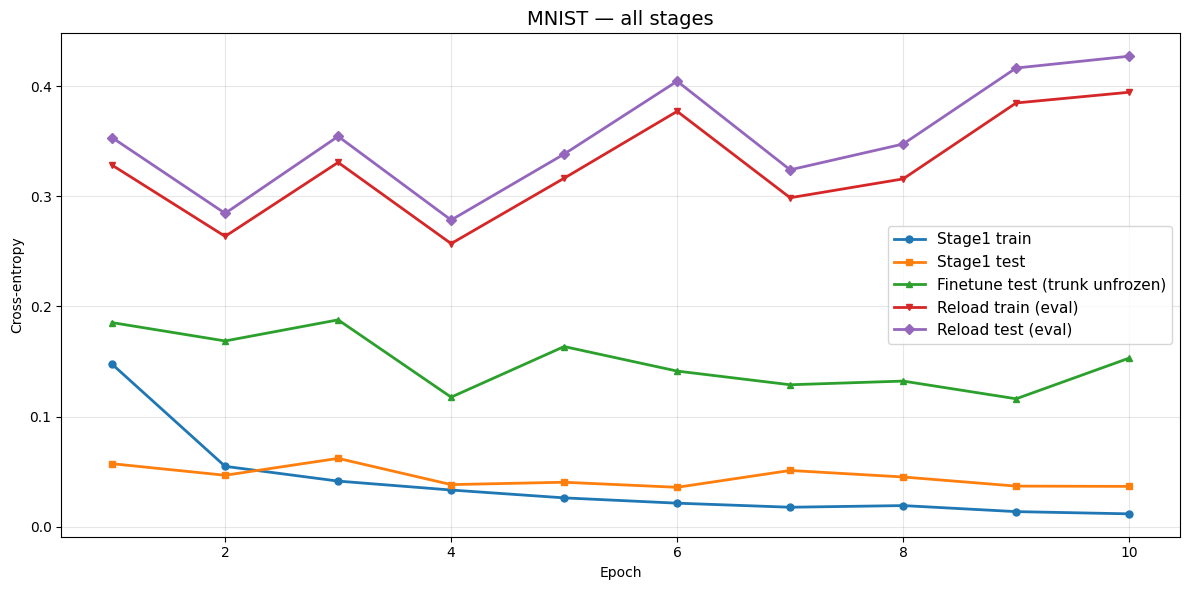

In [13]:
plt.figure(figsize=(12, 6))
ep = range(1, epochs + 1)
plt.plot(ep, mnist_stage1_train, 'o-', linewidth=2, markersize=5, label='Stage1 train')
plt.plot(ep, mnist_stage1_test, 's-', linewidth=2, markersize=5, label='Stage1 test')
plt.plot(ep, mnist_ft_test, '^-', linewidth=2, markersize=5, label='Finetune test (trunk unfrozen)')
plt.plot(ep, reload_mnist_train_eval, 'v-', linewidth=2, markersize=5, label='Reload train (eval)')
plt.plot(ep, reload_mnist_test_eval, 'D-', linewidth=2, markersize=5, label='Reload test (eval)')
plt.title('MNIST — all stages', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

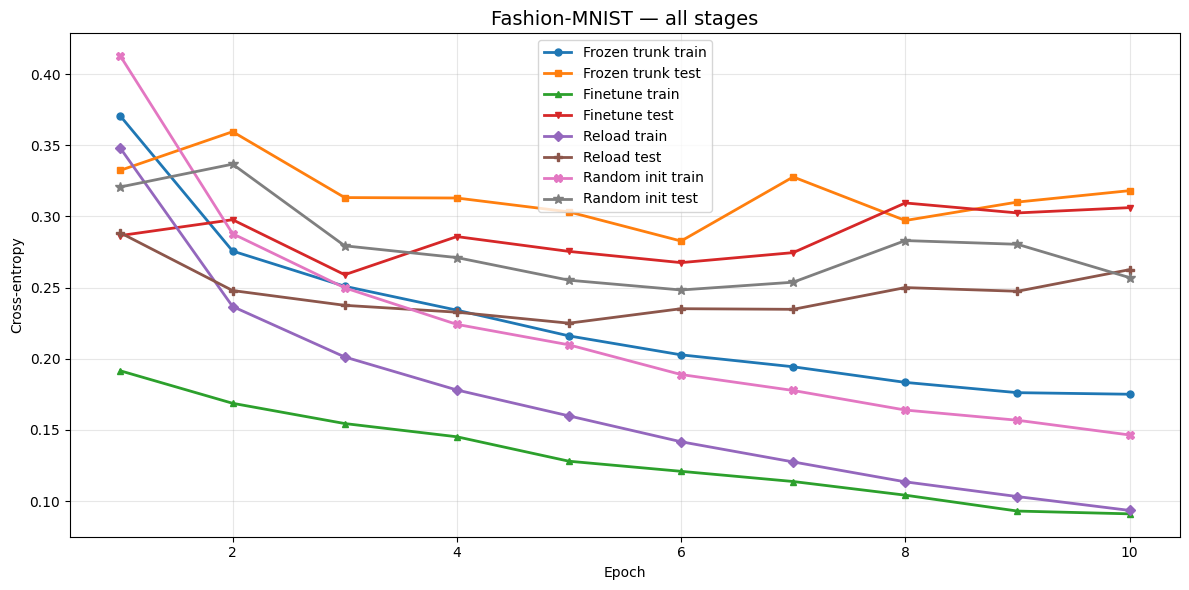

In [14]:
plt.figure(figsize=(12, 6))
ep = range(1, epochs + 1)
plt.plot(ep, fashion_frozen_train, 'o-', linewidth=2, markersize=5, label='Frozen trunk train')
plt.plot(ep, fashion_frozen_test, 's-', linewidth=2, markersize=5, label='Frozen trunk test')
plt.plot(ep, fashion_ft_train, '^-', linewidth=2, markersize=5, label='Finetune train')
plt.plot(ep, fashion_ft_test, 'v-', linewidth=2, markersize=5, label='Finetune test')
plt.plot(ep, reload_fashion_train, 'D-', linewidth=2, markersize=5, label='Reload train')
plt.plot(ep, reload_fashion_test, 'P-', linewidth=2, markersize=6, label='Reload test')
plt.plot(ep, partial_train, 'X-', linewidth=2, markersize=6, label='Random init train')
plt.plot(ep, partial_test, '*-', linewidth=2, markersize=7, label='Random init test')
plt.title('Fashion-MNIST — all stages', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

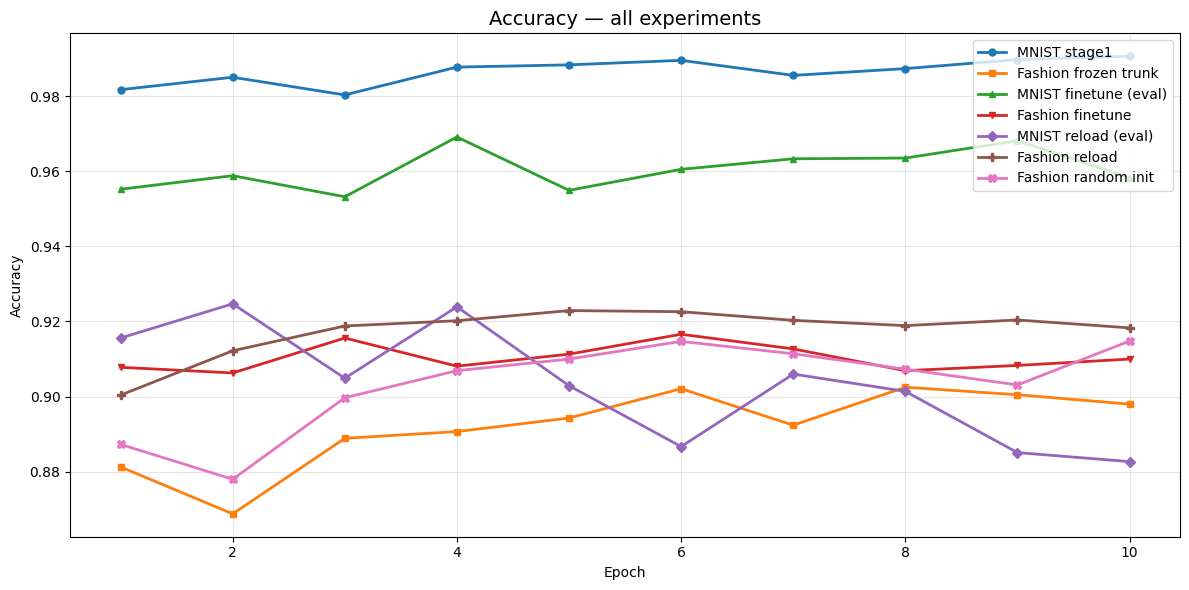

In [15]:
plt.figure(figsize=(12, 6))
ep = range(1, epochs + 1)
plt.plot(ep, mnist_stage1_acc, 'o-', linewidth=2, markersize=5, label='MNIST stage1')
plt.plot(ep, fashion_frozen_acc, 's-', linewidth=2, markersize=5, label='Fashion frozen trunk')
plt.plot(ep, mnist_ft_acc, '^-', linewidth=2, markersize=5, label='MNIST finetune (eval)')
plt.plot(ep, fashion_ft_acc, 'v-', linewidth=2, markersize=5, label='Fashion finetune')
plt.plot(ep, reload_mnist_acc, 'D-', linewidth=2, markersize=5, label='MNIST reload (eval)')
plt.plot(ep, reload_fashion_acc, 'P-', linewidth=2, markersize=6, label='Fashion reload')
plt.plot(ep, partial_acc, 'X-', linewidth=2, markersize=6, label='Fashion random init')
plt.title('Accuracy — all experiments', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

11. Выберете лучшую обученную модель для второй задачи. Опираясь на предсказываемые логиты или вероятности для тестового множества второй задачи, для каждой пары классов c,t найдите изображение класса c, которое больше всего похоже на класс t.

reload 0.9183


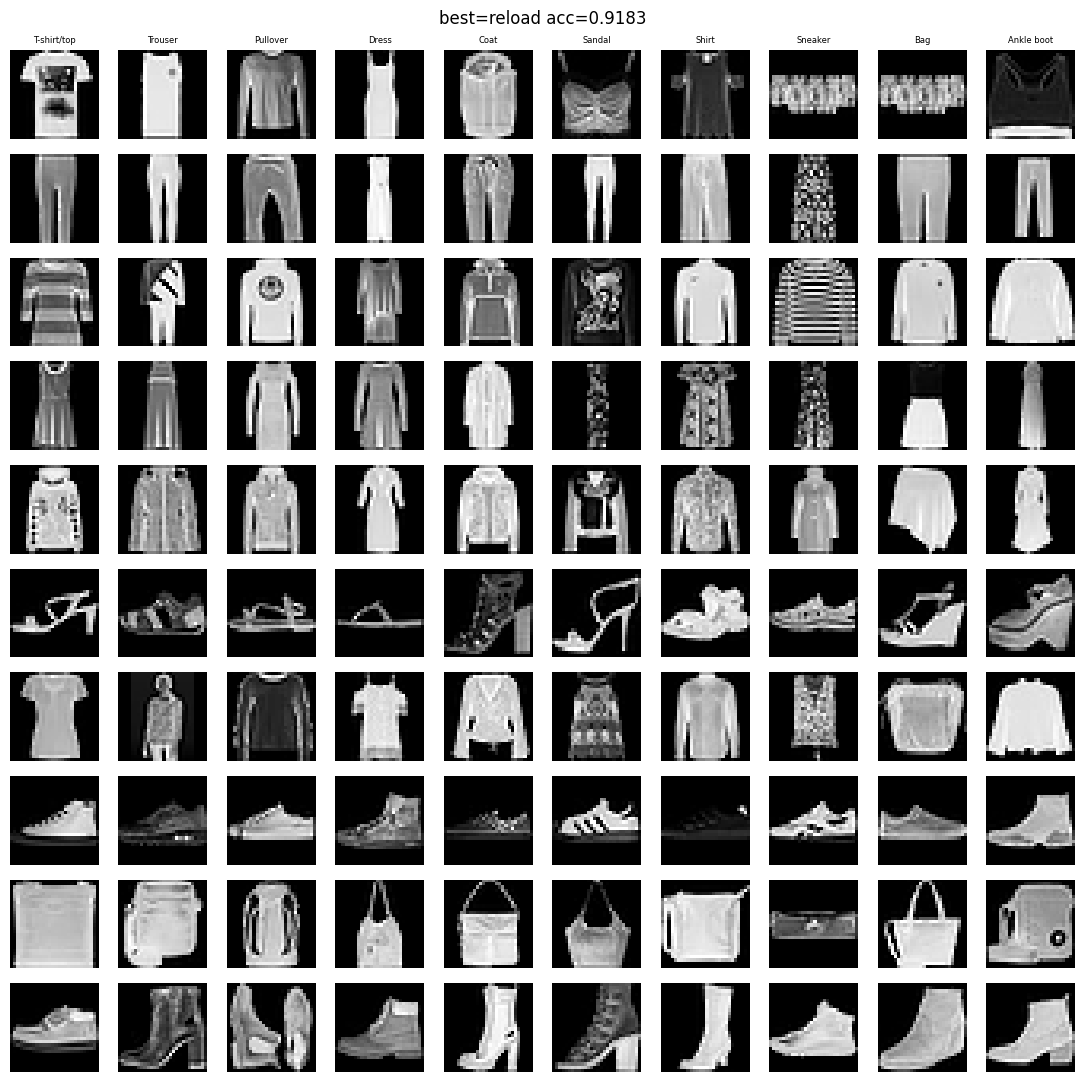

In [16]:
fashion_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

cand = []


def push_from_file(path, tag):
    m = DualHeadCNN().to(device)
    ck = torch.load(path, map_location=device)
    m.stem.load_state_dict(ck["stem"])
    m.body.load_state_dict(ck["body"])
    m.head1.load_state_dict(ck["head1"])
    m.head2.load_state_dict(ck["head2"])
    _, acc = evaluate(m, fashion_test_loader, 2, criterion, device)
    cand.append((acc, tag))


push_from_file("ml2_after_fashion_frozen.pt", "fashion_frozen")
_, a = evaluate(model, fashion_test_loader, 2, criterion, device)
cand.append((a, "finetune"))
_, a = evaluate(model_reload, fashion_test_loader, 2, criterion, device)
cand.append((a, "reload"))
_, a = evaluate(model_partial, fashion_test_loader, 2, criterion, device)
cand.append((a, "partial_random"))

best_acc, best_tag = max(cand, key=lambda z: z[0])
best_model = DualHeadCNN().to(device)
if best_tag == "fashion_frozen":
    ck = torch.load("ml2_after_fashion_frozen.pt", map_location=device)
    best_model.stem.load_state_dict(ck["stem"])
    best_model.body.load_state_dict(ck["body"])
    best_model.head1.load_state_dict(ck["head1"])
    best_model.head2.load_state_dict(ck["head2"])
elif best_tag == "finetune":
    best_model.load_state_dict(model.state_dict())
elif best_tag == "reload":
    best_model.load_state_dict(model_reload.state_dict())
else:
    best_model.load_state_dict(model_partial.state_dict())

print(best_tag, float(best_acc))

best_model.eval()
all_x = []
all_logits = []
all_y = []
with torch.no_grad():
    for x, y in fashion_test_loader:
        x = x.to(device)
        all_x.append(x.cpu())
        all_logits.append(best_model(x, 2).cpu())
        all_y.append(y)

imgs = torch.cat(all_x)
logits = torch.cat(all_logits)
labels = torch.cat(all_y)

grid = {}
for c in range(10):
    for t in range(10):
        msk = labels == c
        sub = logits[msk][:, t]
        j = int(sub.argmax())
        grid[(c, t)] = imgs[msk][j]

fig, axes = plt.subplots(10, 10, figsize=(11, 11))
for c in range(10):
    for t in range(10):
        ax = axes[c, t]
        im = grid[(c, t)].squeeze().numpy() * 0.5 + 0.5
        im = im.clip(0.0, 1.0)
        ax.imshow(im, cmap="gray")
        ax.axis("off")
        if c == 0:
            ax.set_title(fashion_names[t], fontsize=6)
        if t == 0:
            ax.set_ylabel(fashion_names[c], fontsize=6, rotation=90)

plt.suptitle(f"best={best_tag} acc={best_acc:.4f}")
plt.tight_layout()
plt.show()
